<a href="https://colab.research.google.com/github/Ataurcuet-hub/ML-Foundations-for-Research/blob/main/ML_EDA_DataPreprocessing_Feature_Engineering_base_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**End-to-End ML Raw Codes at a glance so that anyone can use these codes according to his necessary project work.**

---






# Outline
## Import Libraries > EDA > Data Preprocessing > Feature Engineering > ML Models > Model Fit > Model Train > Model Evaluate > Model Accuracy

# 1. Import all Imp Libraries for ML:

In [49]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
import warnings; warnings.filterwarnings('ignore')
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [50]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# Load Train Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Heart_Disease_Predic_files/heart_disease_risk_dataset_earlymed.csv')
df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [67]:
# Load Test Dataset
#df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Heart_Disease_Predic_files/test.csv')
#df2.head(10)

# 2. Data Exploration

In [68]:
df.info()
df.describe()
print(f"Missing: {df.isnull().sum().sum()}")   # should print 0
print(f"\n Target Distribution:\n{df['Heart_Risk'].value_counts()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

In [69]:
#test data
#df2.info()
#df2.describe()
#print(f"Missing: {df2.isnull().sum().sum()}")   # should print 0
#print(f"\n Target Distribution:\n{df2['Heart Disease'].value_counts()}")

**Encode Target & Select Numeric Features**

In [70]:
train_dataset=df.copy()
test_dataset=df2.copy()

In [61]:
from sklearn.preprocessing import LabelEncoder

# Encode target: Yes=1, No=0
df['Heart_Risk'] = LabelEncoder().fit_transform(df['Heart_Risk'])

#df.drop(columns=['id'], inplace=True)  #drop ID column
#df2.drop(columns=['id'], inplace=True)  #drop ID column


# Keep only numeric columns for simplicity
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Heart Disease')

X = df[num_cols]
y = df['Heart Disease']
print(X.columns.tolist())
print(y.info())

['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
<class 'pandas.core.series.Series'>
RangeIndex: 630000 entries, 0 to 629999
Series name: Heart Disease
Non-Null Count   Dtype
--------------   -----
630000 non-null  int64
dtypes: int64(1)
memory usage: 4.8 MB
None


**Target Class Check** & ***Data Correlation with Target***

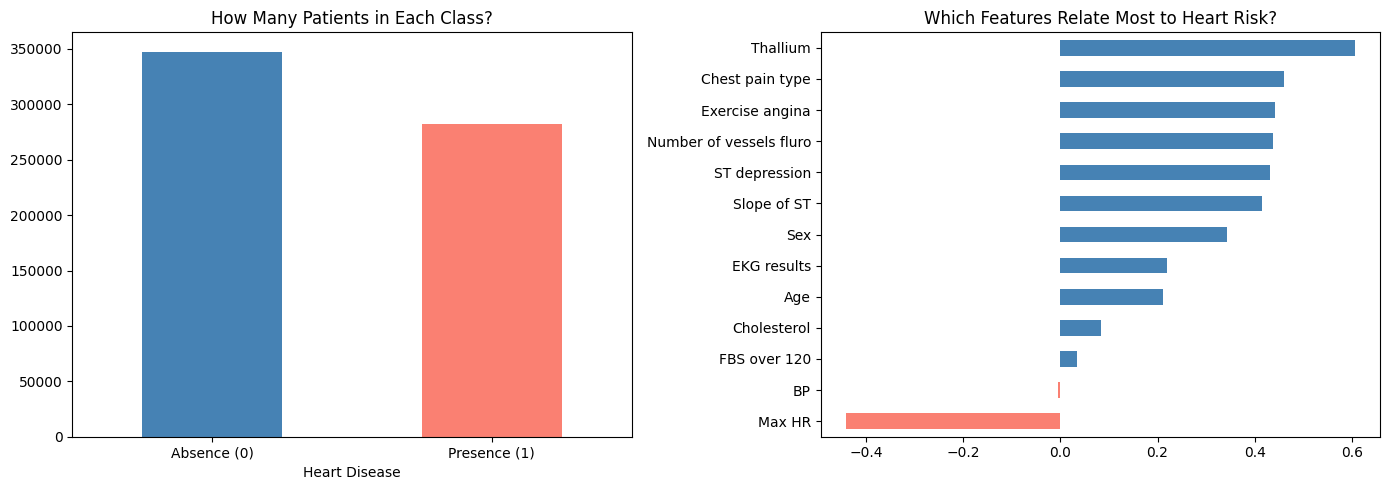

In [62]:
#Target Class Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Heart Disease'].value_counts().plot.bar(ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('How Many Patients in Each Class?')
axes[0].set_xticklabels(['Absence (0)', 'Presence (1)'], rotation=0)

#Data Correlation with Target
corr = df.corr(numeric_only=True)['Heart Disease'].drop('Heart Disease').sort_values()
corr.plot.barh(ax=axes[1], color=['salmon' if v < 0 else 'steelblue' for v in corr])
axes[1].set_title('Which Features Relate Most to Heart Risk?')


plt.tight_layout()
plt.show()

# 3. Data Preprocessing

# Preprocessing Cells | Summery

| Step | Method | Key Rule |
|------|--------|----------|
| Import | `pd.read_csv()` | Load from Drive path |
| Explore | `.info()`, `.describe()` | Understand before touching |
| Missing Values | `.fillna(median/mean/mode)` | Median for skewed, mean for normal, mode for categorical |
| Duplicates | `.drop_duplicates()` | Always remove first |
| Outliers | IQR method | Boxplot to confirm |
| Label Encoding | `LabelEncoder` | Tree-based models |
| One-Hot Encoding | `pd.get_dummies()` | Linear / Neural models |
| StandardScaler | Z-score | SVM, PCA, LogReg |
| MinMaxScaler | [0, 1] range | Neural Networks, KNN |
| RobustScaler | IQR-based | Outlier-heavy data |
| Split | `train_test_split` | Fit scaler on **train only** |

---

**3.1. Data Cleaning:** ***Missing Values, Duplicates***




In [ ]:
# Fill Missing Values
# Numeric → median; Categorical → mode (most frequent)
#df['Farm_Area(acres)'].fillna(df['Farm_Area(acres)'].median(), inplace=True)
#df['Fertilizer_Used(tons)'].fillna(df['Fertilizer_Used(tons)'].mean(), inplace=True)
#df['Water_Usage(cubic meters)'].fillna(df['Water_Usage(cubic meters)'].median(), inplace=True)
#df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)

#df.isnull().sum().sum()  # should be 0

In [45]:
# Duplicates & Clean
#data.drop_duplicates(inplace=True)
#data.drop(columns=['Farm_ID'], inplace=True)
#for col in df.select_dtypes(include=np.number).columns:
 #  q1, q3 = df[col].quantile([0.25, 0.75])
  # iqr = q3 - q1
 #  df = df[df[col].between(q1 - 1.5*iqr, q3 + 1.5*iqr)]

NameError: name 'data' is not defined

**Outliers**

In [46]:
# Dictionary for Outlier counting
outliers_summary = {}

for col in df.select_dtypes(include=np.number).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # find out Number of Outliers
    num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outliers_summary[col] = num_outliers

# Outliers Result in Table
outliers_df = pd.DataFrame(list(outliers_summary.items()), columns=['Column', 'Outliers Count'])
print(outliers_df)

                     Column  Outliers Count
0                       Age            1048
1                       Sex               0
2           Chest pain type           28602
3                        BP            9011
4               Cholesterol            2194
5              FBS over 120           50392
6               EKG results               0
7                    Max HR           14246
8           Exercise angina               0
9             ST depression            9971
10              Slope of ST               0
11  Number of vessels fluro           22857
12                 Thallium               0
13            Heart Disease               0


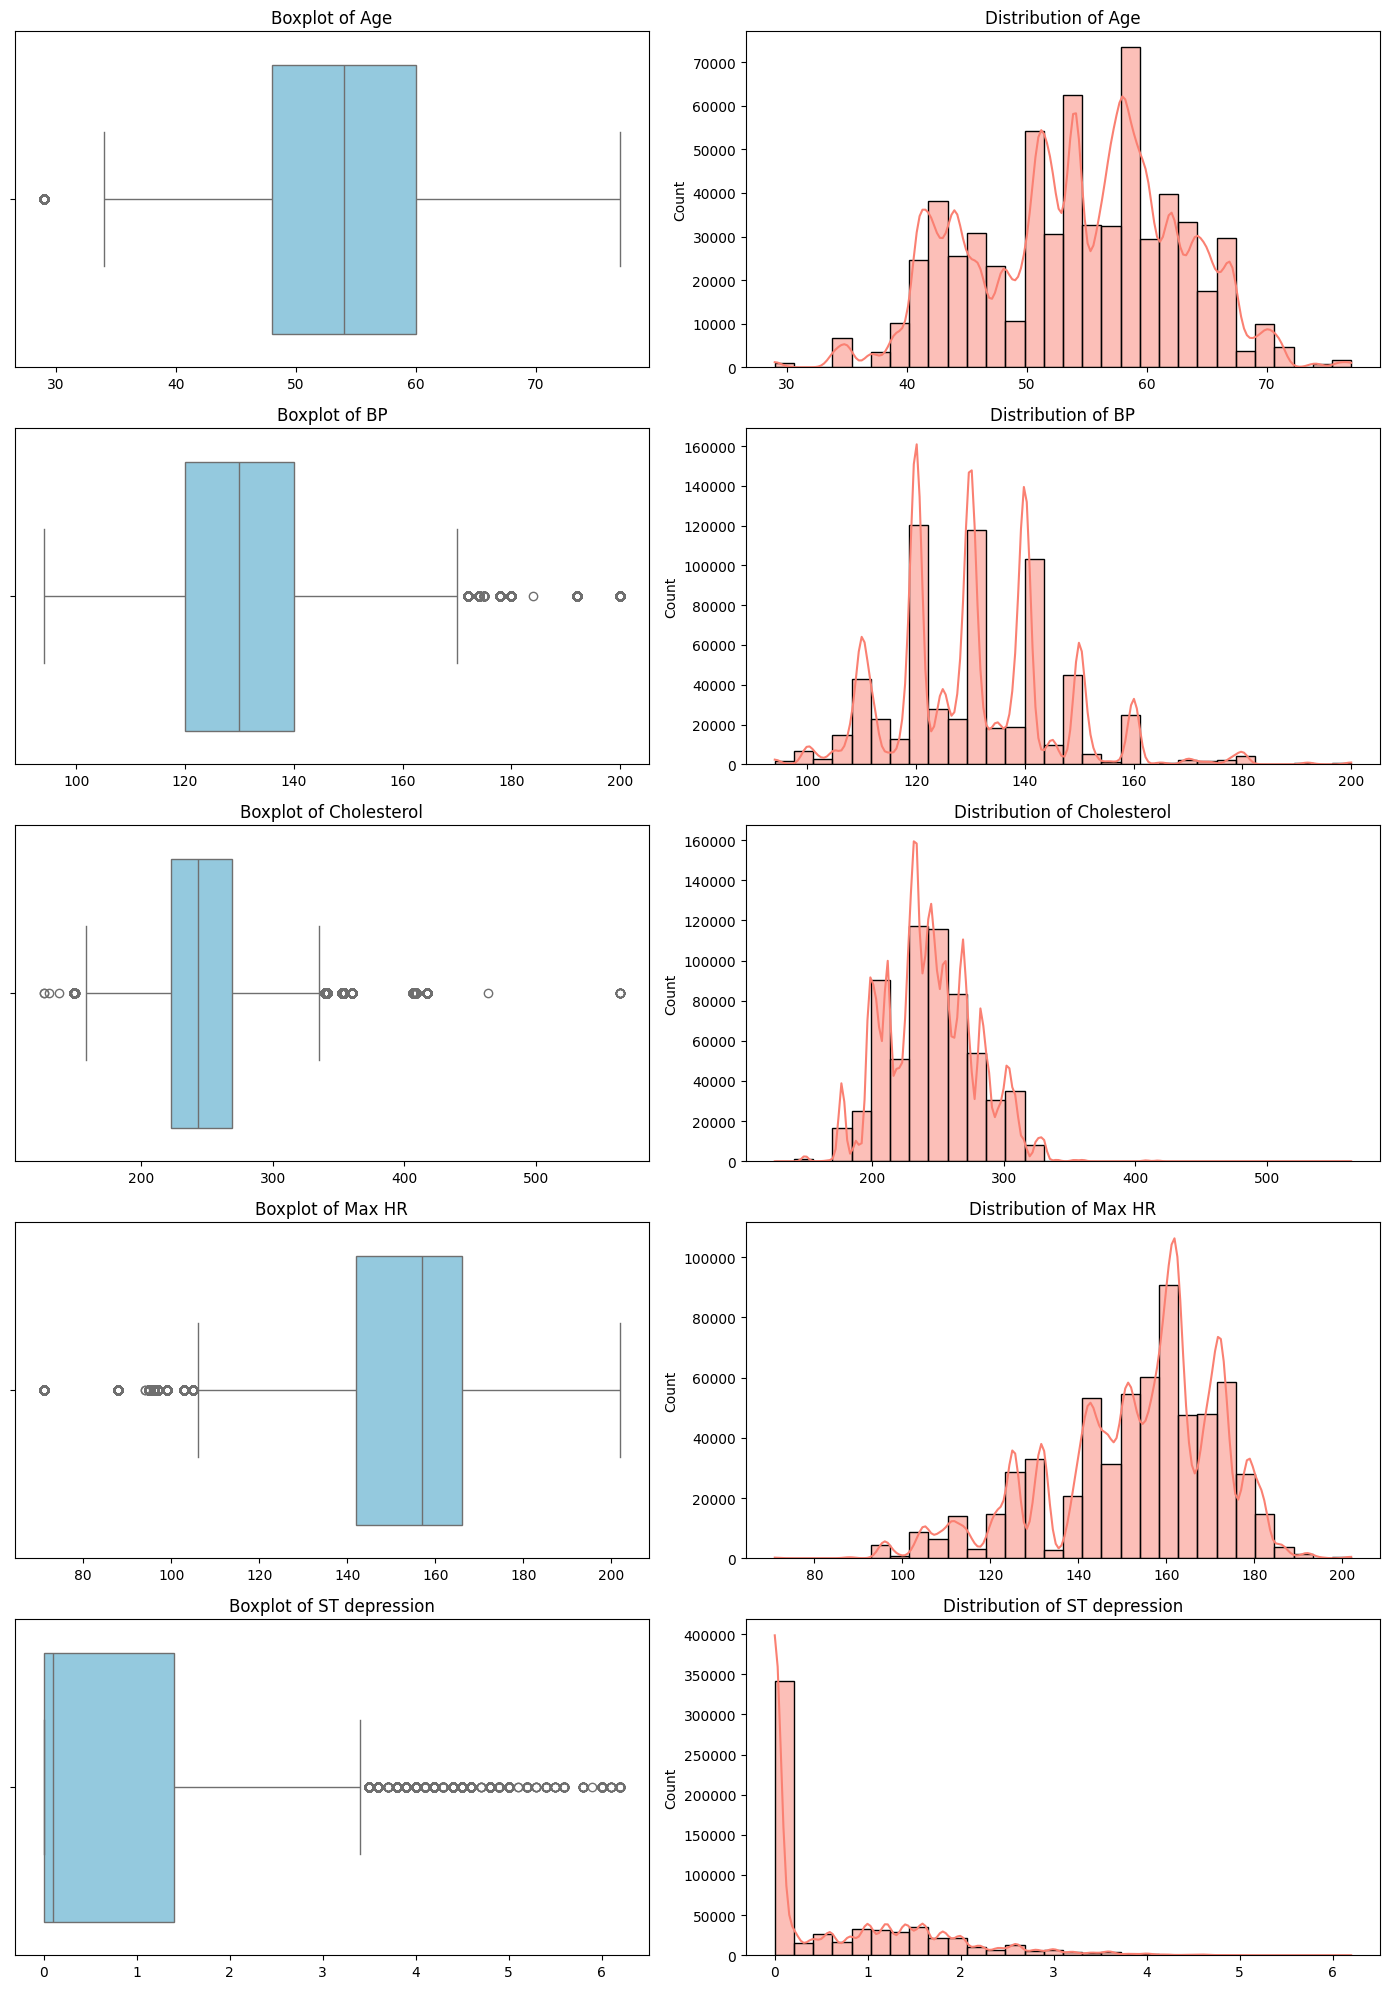

In [63]:
# List for continous columns

continuous_cols = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]

# Set Subplots spacing
fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(14, 4 * len(continuous_cols)))

for i, col in enumerate(continuous_cols):
    # Left Side: Boxplot (Outlier visualization)
    sns.boxplot(x=df[col], ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"Boxplot of {col}", fontsize=12)
    axes[i, 0].set_xlabel("")

    # Right Side: Histogram/KDE (Skewness and Distribution)
    sns.histplot(df[col], kde=True, ax=axes[i, 1], color="salmon", bins=30)
    axes[i, 1].set_title(f"Distribution of {col}", fontsize=12)
    axes[i, 1].set_xlabel("")

# Layout tight and clean korar jonno
plt.tight_layout()
plt.show()

**Outlier Handling**

In [64]:
# ১. Target continuous columns (Age chara)
cols_to_cap = ["BP", "Cholesterol", "Max HR", "ST depression"]

# ২. Loop generate kore 1st and 99th percentile cap apply kora
for col in cols_to_cap:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)

    # np.clip diye nicher value ke lower_limit ar uporer value ke upper_limit e set kora
    df[col] = np.clip(df[col], lower_limit, upper_limit)

    print(f"Capped {col:12} -> Lower Limit: {lower_limit:<6} | Upper Limit: {upper_limit}")

print("\nCapping successfully done!")

Capped BP           -> Lower Limit: 100.0  | Upper Limit: 178.0
Capped Cholesterol  -> Lower Limit: 177.0  | Upper Limit: 325.0
Capped Max HR       -> Lower Limit: 103.0  | Upper Limit: 182.0
Capped ST depression -> Lower Limit: 0.0    | Upper Limit: 3.6

Capping successfully done!


In [48]:
df_capped = df.copy()

for col in df_capped.select_dtypes(include=np.number).columns:
    q1 = df_capped[col].quantile(0.25)
    q3 = df_capped[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Replace within Boundary
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound,
                       np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col]))

print("Outlier Capping completed")

Outlier Capping completed


**3.2. Encoding Categorical Data**

In [ ]:
#Label Encoding
cat_cols = ['Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']
df_enc = df.drop(columns=['Farm_ID']).copy()

# Label Encoding — best for tree-based models
le = LabelEncoder()
df_enc['Season_LE'] = le.fit_transform(df_enc['Season'])
df_enc.head(10)

In [ ]:
# One-Hot Encoding — best for linear / neural models
df_ohe = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)
df_ohe.head(3)


**3.3 Scaling & Normalization**

In [ ]:
X_num = df[num_cols].copy()
yield_idx = num_cols.index('Yield(tons)')

scalers = {
    'Original'       : X_num['Yield(tons)'],
    'StandardScaler'  : pd.Series(StandardScaler().fit_transform(X_num)[:, yield_idx]),
    'MinMaxScaler'    : pd.Series(MinMaxScaler().fit_transform(X_num)[:, yield_idx])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=9)
plt.suptitle('Yield — Scaling Comparison', fontweight='bold'); plt.tight_layout(); plt.show()

# 4.Feature Engineering

**4.1. Change/manipulate Columns According to Domain Need**

In [ ]:
# Feature 1: Annual income per year at company

X['income_per_year'] = (X['Monthly_Income'] * 12) / (X['Years_at_Company'] + 1)

# Feature 2: Loyalty ratio using number of companies worked
# Fewer companies = more loyal; inverse of job-hopping tendency
X['loyalty_ratio'] = X['Years_at_Company'] / (X['Number_of_Companies_Worked'] + 1)

X[['income_per_year', 'loyalty_ratio']].head()

**4.2. PolyNomial Features**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_features = poly.fit_transform(X[['Age', 'Monthly_Income', 'Job_Satisfaction']])

feature_names = poly.get_feature_names_out(['Age', 'Monthly_Income', 'Job_Satisfaction'])
poly_df = pd.DataFrame(poly_features, columns=feature_names)

print(f"Shape: {poly_features.shape}")
print(f"Features: {list(feature_names)}\n")
print(poly_df.head())
print(poly_df.describe().round(2))

**DO After 1/2: (a) Filter Method ___ Correlation with target**

In [ ]:
import matplotlib.pyplot as plt

# Add the newly engineered features from X to df so they can be used for correlation
df['income_per_year'] = X['income_per_year']
df['loyalty_ratio'] = X['loyalty_ratio']

corr = df[num_cols + ['income_per_year', 'loyalty_ratio', 'Attrition']].corr()['Attrition'].drop('Attrition').sort_values()
print(corr.round(4).to_string())
corr.plot(kind='barh', figsize=(6,6), title='Correlation with Attrition')
plt.tight_layout()
plt.show()

**(b) Filter Method __ CHi-Square Test**

In [ ]:
from sklearn.feature_selection import chi2, SelectKBest

# Chi-square needs non-negative values
X_pos = X - X.min()

chi_selector = SelectKBest(chi2, k=5)
chi_selector.fit(X_pos, y)

chi_scores = pd.Series(chi_selector.scores_, index=X.columns)
chi_scores.nlargest(5)

**(c) Filter Method__ Mutual Information**

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores.head(7)

**(d) Wrapper Method__ RFE**

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=5)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_].tolist()
print("RFE selected:", rfe_features)

**(e) Embedded Method__Lasso**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1, random_state=42)
lasso.fit(X_scaled, y)

lasso_imp = pd.Series(abs(lasso.coef_[0]), index=X.columns)
print("Lasso non-zero features:")
print(lasso_imp[lasso_imp > 0].sort_values(ascending=False))

**(f) Embedded Method__Tree-based Importance**

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.round(4))
imp.head(7).plot(kind='bar', title='Tree-based Feature Importance')
plt.tight_layout()
plt.show()

***5.3. Activity_ Compare With vs Without Feature Selection***

In [ ]:
from sklearn.model_selection import cross_val_score

# All features
score_all = cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=5).mean()

# Top 5 features from RFE
score_rfe = cross_val_score(RandomForestClassifier(random_state=42), X[rfe_features], y, cv=5).mean()

# Top 5 from mutual info
top5_mi = mi_scores.head(5).index.tolist()
score_mi = cross_val_score(RandomForestClassifier(random_state=42), X[top5_mi], y, cv=5).mean()

results = pd.DataFrame({
    'Method': ['All Features', 'RFE (5)', 'Mutual Info (5)'],
    'Accuracy': [round(score_all,4), round(score_rfe,4), round(score_mi,4)]
})
results

**5.4. Visual COmparision of Features**

In [ ]:
plt.bar(results['Method'], results['Accuracy'], color=['#e74c3c','#3498db','#2ecc71'])
plt.ylim(0.7, 1.0)
plt.title('Accuracy: All Features vs Selected Features')
plt.ylabel('CV Accuracy')
plt.tight_layout()
plt.show()

# 6. Train Test Split

In [ ]:
X = df_ohe.drop(columns=['Yield(tons)', 'Season_LE'], errors='ignore')
y = df['Yield(tons)'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f'Pipeline complete → X_train: {X_train.shape}  |  X_test: {X_test.shape}')

plt.figure(figsize=(4, 4))
plt.pie([len(X_train), len(X_test)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A','#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('Train-Test Split'); plt.show()




# 5. Train the Model

# 5.1 Decision Tree
Now the exciting part — we train the model! This means: *"Hey model, look at these 56,000 patients and figure out the pattern."*

`max_depth=5` means the tree can ask up to 5 yes/no questions deep. This prevents the tree from getting too complex.









In [ ]:
# Train the Decision Tree
model = DecisionTreeClassifier(max_depth=5, random_state=20)
model.fit(X_train, y_train)
print("✅ Model training complete!")

# 6. Make Prediction & Check Accuracy
Now we ask the trained model to predict Heart_Risk for the 14,000 test patients it has **never seen before**.


In [ ]:
# 7. Predictions & Accuracy
predictions = model.predict(X_test)
prediction_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, predictions)
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 7. Confusion Matrics

Accuracy alone doesn't tell the full story. The **Confusion Matrix** shows exactly *where* the model made mistakes:

|  | Actual Positive (High Risk) | Actual Negative (Low Risk) |
|--|---|---|
| **Predicted Positive (High Risk)** | ✅ True Positive (TP) | ❌ False Positive (FP) — false alarm |
| **Predicted Negative (Low Risk)** | ❌ False Negative (FN) — missed! | ✅ True Negative (TN) |

**False Negatives are dangerous here** — the model missed a real high-risk patient!

In [ ]:
# 8. Confusion Matrix — Layout: [[TP, FP], [FN, TN]]
cm = confusion_matrix(y_test, predictions, labels=[1, 0]).T  # Transpose for TP top-left, FP top-right

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Actual: High Risk', 'Actual: Low Risk'],
            yticklabels=['Pred: High Risk', 'Pred: Low Risk'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

# Bar chart: TP, FP, FN, TN
TP, FP, FN, TN = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
labels = ['TP\n(Correct)', 'FP\n(False Alarm)', 'FN\n(Missed!)', 'TN\n(Correct)']
vals = [TP, FP, FN, TN]
axes[1].bar(labels, vals, color=['seagreen', 'orange', 'salmon', 'steelblue'])
axes[1].set_title('Prediction Breakdown')
for i, v in enumerate(vals):
    axes[1].text(i, v + max(vals)*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"✅ Correct: {TP+TN:,} | ❌ Wrong: {FP+FN:,}")

## 8. Performance Scores <a id='9'></a>

Let's look at 4 key metrics:

| Metric | What It Means (Simple) |
|--------|----------------------|
| **Accuracy** | Overall, how often is the model correct? |
| **Precision** | When it says "High Risk", how often is it right? |
| **Recall** | Out of all actual High Risk patients, how many did it catch? |
| **F1-Score** | A balanced mix of Precision and Recall |


In [ ]:
# 8. Performance Scores
accuracy  = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall    = recall_score(y_test, predictions)
f1        = f1_score(y_test, predictions)

print(f"Accuracy : {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


In [ ]:
# Visual comparison
fig, ax = plt.subplots(figsize=(7, 4))
names, vals = ['Accuracy', 'Precision', 'Recall', 'F1-Score'], [accuracy, precision, recall, f1]
bars = ax.bar(names, vals, color=['steelblue', 'seagreen', 'orange', 'salmon'])
ax.set_ylim(0, 1.1); ax.set_title('How Good Is Our Model?')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 9. ROC Curve & AUC Score
The **ROC Curve** shows how well the model separates the two classes across *all possible thresholds*.

- **AUC = 1.0** → Perfect model
- **AUC = 0.5** → Random guessing (useless)
- **AUC > 0.9** → Excellent

In [ ]:
# 9. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, prediction_proba)
auc = roc_auc_score(y_test, prediction_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC: {auc:.4f}")

10. Quick Summery
| Step | What We Did |
|------|------------|
| Load Data | Read 70,000 patient records from CSV |
| Explore | Checked for missing data, looked at distributions |
| Prepare | Separated features (X) from target (y) |
| Split | 80% training, 20% testing |
| Train | Decision Tree with max_depth=5 |
| Evaluate | Accuracy, Precision, Recall, F1, ROC-AUC |

**Result:** Our simple Decision Tree achieved ~94% accuracy and ~0.98 AUC — quite strong for a first model!

---